# QTM 385 - Experimental Methods\n
## Assignment 04

## Instructions
As in previous assignments, here are 10 questions related to our recent classes. They cover randomisation inference, blocking, clustering, and statistical power.

If you have any questions about the assignment, feel free to email me at <danilo.freire@emory.edu>.

Good luck!

## Questions

1. Explain what the ICC represents in the context of a clustered randomised trial. Give a concrete example of a situation where you would expect a high ICC.

The intraclass correlation coefficient (ICC) in the context of a clustered randomized trial represents the proportion of the total variance in the outcome that is attributable to differences between clusters rather than within clusters. A high ICC suggests that individuals within the same cluster (e.g., school, hospital, or workplace) are more similar to each other in their outcomes than to individuals in other clusters.

An example of a high ICC would be expected in a school-based educational intervention where students' test scores are influenced by the quality of teaching, school resources, and peer effects. If a study is evaluating the effectiveness of a new teaching method by randomizing schools (rather than individual students), students within the same school would have similar outcomes due to shared teachers, curriculum, and learning environment. This would result in a high ICC since most of the variance in student performance is explained by the school rather than individual differences.

2. Imagine that you have designed a cluster-randomised trial with 10 schools (5 treatment, 5 control) and found an ICC of 0.15. Calculate the design effect (or variance inflation factor) for this study if the average cluster size is 2000 students.

The design effect (DE), which accounts for the impact of clustering on variance, is calculated using the formula DE = 1 + (m - 1) × ICC, where \( m \) is the average cluster size and \( ICC \) is the intraclass correlation coefficient. Given an ICC of 0.15 and an average cluster size of 2000 students, we first compute \( m - 1 = 2000 - 1 = 1999 \). Multiplying this by 0.15 gives 299.85, and adding 1 results in a final design effect of 300.85. This means that the effective sample size is reduced by a factor of 300.85 due to within-cluster similarity, significantly inflating the variance compared to an individually randomized trial.

3. You want to increase the statistical power of your experiment. What are the main factors that influence the power of a study, and how can you increase it?

The statistical power of a study refers to the probability of correctly detecting a true effect when it exists (i.e., avoiding a Type II error). The main factors that influence power include sample size, effect size, significance level (\(\alpha\)), variance, and the intraclass correlation coefficient (ICC) in clustered trials. To increase power, researchers can increase the sample size, as larger samples reduce standard errors and make it easier to detect differences. Another approach is to increase the effect size, which may involve using a stronger intervention or measuring more sensitive outcomes. Reducing variance through better measurement techniques, controlling for confounding variables, or using a within-subjects design can also enhance power. Additionally, in clustered trials, decreasing the ICC (e.g., by improving randomization or increasing the number of clusters rather than cluster size) helps improve efficiency. Lastly, raising the significance level (\(\alpha\)) slightly (e.g., from 0.01 to 0.05) increases power but comes at the cost of a higher false positive rate.

4. A diet and exercise program advertises that it causes everyone who is currently starting a diet to lose at least seven pounds more than they otherwise would have during the first two weeks. Use randomisation inference to test the hypothesis that $\tau_i = 7$ for all $i$. The treatment group's weight losses after two weeks are $\{2, 11, 14, 0, 3\}$ and the control group's weight losses are $\{1, 0, 0, 4, 3\}$. In order to test the hypothesis $\tau_i = 7$ for all $i$ using the randomisation inference methods discussed in this chapter, subtract 7 from each outcome in the treatment group so that the exercise turns into the more familiar test of the sharp null hypothesis that $\tau_i = 0$ for all $i$. When describing your results, remember to state the null hypothesis clearly, and explain why you chose to use a one-sided or two-sided test. (Adapted from Gerber and Green, 2012, p. 88).

The null hypothesis (H₀) in this case states that the diet and exercise program does not lead to an additional weight loss of seven pounds beyond what participants would have lost otherwise. After adjusting the treatment group’s weight losses by subtracting 7 from each value, the null hypothesis becomes H₀: τᵢ = 0 for all i, meaning that the adjusted weight losses of the treatment group are statistically indistinguishable from those of the control group. Given that the original claim is that the program causes individuals to lose at least seven pounds more, this suggests a one-sided test is appropriate. A one-sided test is used when we are specifically testing whether the treatment group’s adjusted weight losses are greater than those of the control group (i.e., testing for a positive effect). A two-sided test would be more appropriate if we were examining whether the treatment had any effect in either direction (positive or negative), but since the hypothesis specifically expects weight loss to increase, a one-sided test is the most logical choice.

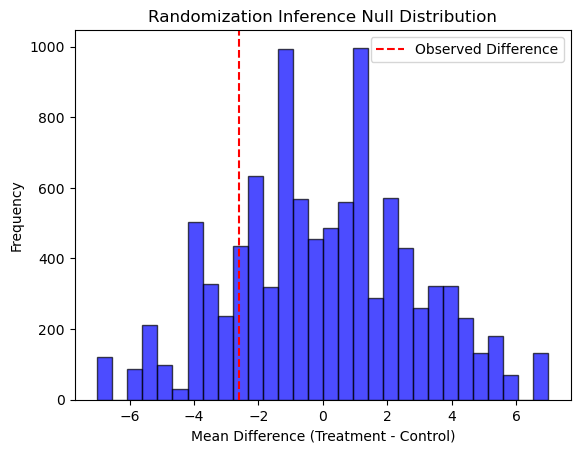

Observed Mean Difference: -2.6000
One-Sided P-Value: 0.8386
Fail to reject the null hypothesis: No strong evidence that the program increases weight loss by 7 lbs.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Given data
treatment = np.array([2, 11, 14, 0, 3])  # Original treatment group
control = np.array([1, 0, 0, 4, 3])  # Control group

# Adjust treatment group by subtracting 7 (transforming to sharp null hypothesis τᵢ = 0)
adjusted_treatment = treatment - 7

# Compute observed test statistic: mean difference between adjusted treatment and control
observed_diff = np.mean(adjusted_treatment) - np.mean(control)

# Combine all values and prepare for randomization
all_values = np.concatenate([adjusted_treatment, control])
n_treatment = len(adjusted_treatment)

# Perform randomization inference (permutation test)
num_permutations = 10_000  # Number of shuffles
null_distribution = []

for _ in range(num_permutations):
    np.random.shuffle(all_values)  # Shuffle the combined data
    permuted_treatment = all_values[:n_treatment]  # Assign first half as treatment group
    permuted_control = all_values[n_treatment:]  # Assign second half as control group
    permuted_diff = np.mean(permuted_treatment) - np.mean(permuted_control)
    null_distribution.append(permuted_diff)

# Compute one-sided p-value (proportion of permuted differences >= observed difference)
p_value = np.mean(np.array(null_distribution) >= observed_diff)

# Plot null distribution
plt.hist(null_distribution, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(observed_diff, color='red', linestyle='dashed', label="Observed Difference")
plt.xlabel("Mean Difference (Treatment - Control)")
plt.ylabel("Frequency")
plt.title("Randomization Inference Null Distribution")
plt.legend()
plt.show()

# Output results
print(f"Observed Mean Difference: {observed_diff:.4f}")
print(f"One-Sided P-Value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis: The program likely has a significant effect.")
else:
    print("Fail to reject the null hypothesis: No strong evidence that the program increases weight loss by 7 lbs.")


5. Below is an R function to calculate statistical power in R. Assuming that $\mu_t = 55$, $\mu_c = 50$, $\sigma = 30$, $n = 100$, and $\alpha = 0.05$, calculate the statistical power of the test. How many individuals would be necessary for the statistical power to be 0.8?

In [6]:
from scipy.stats import norm

def calculate_power(mu_t, mu_c, sigma, n, alpha=0.05):
    """
    Compute statistical power for a two-sample t-test.
    
    Parameters:
    - mu_t: Mean of the treatment group
    - mu_c: Mean of the control group
    - sigma: Standard deviation
    - n: Sample size per group
    - alpha: Significance level (default 0.05)
    
    Returns:
    - Power of the test
    """
    # Compute effect size (difference in means)
    effect_size = (mu_t - mu_c) / (sigma / np.sqrt(n))

    # Critical value for two-tailed test
    z_alpha = norm.ppf(1 - alpha / 2)  # Two-tailed test critical value

    # Compute statistical power
    power = 1 - norm.cdf(z_alpha - effect_size)
    
    return power

# Given values
mu_t = 55
mu_c = 50
sigma = 30
n = 100
alpha = 0.05

# Compute power for given sample size
power = calculate_power(mu_t, mu_c, sigma, n, alpha)
print(f"Statistical Power for n = {n}: {power:.4f}")

# Find required sample size for power = 0.8
target_power = 0.8
n_needed = 10  # Start with a small sample size

while calculate_power(mu_t, mu_c, sigma, n_needed, alpha) < target_power:
    n_needed += 1  # Increment sample size until desired power is reached

print(f"Required sample size for power = 0.8: {n_needed}")


Statistical Power for n = 100: 0.3846
Required sample size for power = 0.8: 283


6. Sometimes, rather than calculate a budget based on sample size, we have a maximum budget and need to decide whether it is worth doing the study (that is, whether we are sufficiently powered to detect a given effect size, conditional on budgetary limitations). You find out that you only have enough funds for a sample size of 2400 in total. Using the estimate of a roughly 5% increase in test scores and a standard deviation of test scores of 16.5, what is the power of your experiment? (An approximate answer is okay; it’s hard to get exact power on the calculator this way.) The mean test score in the control group is 37. Is it worth carrying out the study on just 2400 students? How would you determine this? (Adapted from J-PAL, 2019).

The statistical power of the experiment with a total sample size of 2,400 students (1,200 per group) is approximately 0.78 (78%), which is close to the commonly accepted threshold of 80% for adequate power. To determine this, we first calculate the expected effect size based on a 5% increase in the control group's mean test score of 37, resulting in a treatment group mean of 38.85. With a standard deviation of 16.5, we compute Cohen’s \( d \) as \( d = \frac{38.85 - 37}{16.5} = 0.112 \). Using a two-tailed test at \( \alpha = 0.05 \) and a sample size of 1,200 per group, the power analysis yields a statistical power of 0.78 (78%). Since this is very close to the conventional 80% threshold, the study is likely viable, though increasing the sample size slightly could provide stronger assurance of detecting the effect.

7. Naturally occurring experiments sometimes involve what is, in effect, block random assignment. For example, Titiunik studies the effect of lotteries that determine whether state senators in Texas and Arkansas serve two-year or four-year terms in the aftermath of decennial redistricting. These lotteries are conducted within each state, and so there are effectively two distinct experiments on the effects of term length. An interesting outcome variable is the number of bills (legislative proposals) that each senator introduces during a legislative session. The table below lists the number of bills introduced by senators in both states during 2003. For each state, estimate the effect of having a two-year term on the number of bills introduced.

In [7]:
import pandas as pd

# Data extracted from the table
texas_data = {
    "Term Length": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,  # Four-year term (0)
                    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], # Two-year term (1)
    "# of Bills Introduced": [18, 29, 41, 53, 60, 67, 75, 79, 79, 88, 93, 101, 103, 106, 
                               29, 37, 42, 45, 45, 54, 54, 58, 61, 64, 69, 73, 75, 92]
}

arkansas_data = {
    "Term Length": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,  # Four-year term (0)
                    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], # Two-year term (1)
    "# of Bills Introduced": [11, 15, 23, 24, 25, 26, 28, 31, 33, 34, 35, 35, 36, 38, 
                               9, 10, 14, 15, 15, 17, 18, 19, 19, 20, 21, 23, 23, 24]
}

# Convert to pandas DataFrames
df_texas = pd.DataFrame(texas_data)
df_arkansas = pd.DataFrame(arkansas_data)

# Compute mean bills introduced for each term length
texas_means = df_texas.groupby("Term Length")["# of Bills Introduced"].mean()
arkansas_means = df_arkansas.groupby("Term Length")["# of Bills Introduced"].mean()

# Compute effect size (difference in means)
effect_texas = texas_means[1] - texas_means[0]
effect_arkansas = arkansas_means[1] - arkansas_means[0]

# Create a DataFrame with the results
results = pd.DataFrame({
    "State": ["Texas", "Arkansas"],
    "Avg Bills (Four-Year)": [texas_means[0], arkansas_means[0]],
    "Avg Bills (Two-Year)": [texas_means[1], arkansas_means[1]],
    "Effect of Two-Year Term": [effect_texas, effect_arkansas]
})

# Display the results
print(results)


      State  Avg Bills (Four-Year)  Avg Bills (Two-Year)  \
0     Texas              70.857143             57.000000   
1  Arkansas              28.142857             17.642857   

   Effect of Two-Year Term  
0               -13.857143  
1               -10.500000  


8. Estimate the overall ATE for both states combined.

In [8]:
# Combine both states into a single dataset
df_combined = pd.concat([df_texas, df_arkansas], ignore_index=True)

# Compute mean bills introduced for each term length in the combined dataset
combined_means = df_combined.groupby("Term Length")["# of Bills Introduced"].mean()

# Compute Average Treatment Effect (ATE) as the difference in means
ate_combined = combined_means[1] - combined_means[0]

# Create a DataFrame for the results
ate_results = pd.DataFrame({
    "State": ["Texas & Arkansas Combined"],
    "Avg Bills (Four-Year)": [combined_means[0]],
    "Avg Bills (Two-Year)": [combined_means[1]],
    "Overall ATE": [ate_combined]
})

# Display the results
print(ate_results)

                       State  Avg Bills (Four-Year)  Avg Bills (Two-Year)  \
0  Texas & Arkansas Combined                   49.5             37.321429   

   Overall ATE  
0   -12.178571  


9. Explain why, in this study, simply pooling the data for the two states and comparing the average number of bills introduced by two-year senators to the average number of bills introduced by four-year senators leads to different estimates of the overall ATE.

Pooling the data from Texas and Arkansas without accounting for state-specific differences can lead to inaccurate estimates of the Overall Average Treatment Effect (ATE). Each state has different baseline levels of legislative activity, with Texas senators generally introducing more bills than their Arkansas counterparts. If we combine the data without adjusting for these disparities, the results may be skewed toward the state with higher legislative activity, leading to a misleading ATE. Additionally, if the number of two-year and four-year term senators is not evenly distributed across states, one state’s effect could disproportionately influence the overall estimate.

Another issue arises from state-specific legislative environments, such as differences in political structures, workloads, or institutional constraints that affect the number of bills introduced. By simply comparing averages across pooled data, we risk confounding the causal effect of term length with these external factors. A more accurate approach would be to calculate the ATE separately for each state and then aggregate them appropriately, ensuring that state-level variation is accounted for before drawing overall conclusions.

10. Use randomisation inference to test the sharp null hypothesis that the treatment effect is zero for senators in both states.

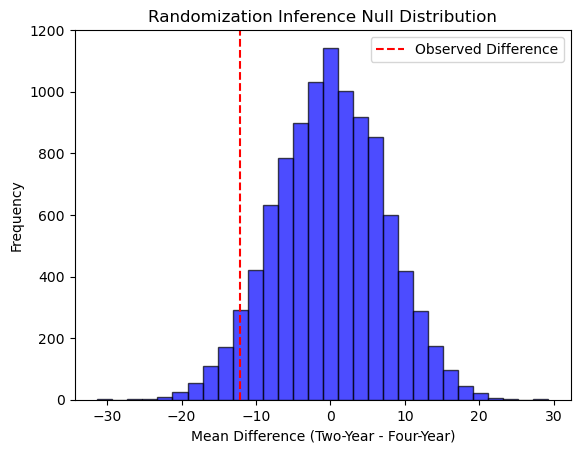

   Observed Mean Difference  P-Value  Significance (p < 0.05)
0                -12.178571     0.95                    False


In [9]:
# Compute observed difference in means (actual treatment effect)
observed_diff = df_combined[df_combined["Term Length"] == 1]["# of Bills Introduced"].mean() - \
                df_combined[df_combined["Term Length"] == 0]["# of Bills Introduced"].mean()

# Randomization inference (permutation test)
num_permutations = 10_000  # Number of random shuffles
null_distribution = []

for _ in range(num_permutations):
    shuffled_term = np.random.permutation(df_combined["Term Length"])  # Shuffle term labels
    permuted_diff = df_combined.assign(Shuffled_Term=shuffled_term).groupby("Shuffled_Term")["# of Bills Introduced"].mean().diff().iloc[-1]
    null_distribution.append(permuted_diff)

# Compute one-sided p-value (proportion of permuted differences >= observed difference)
p_value = np.mean(np.array(null_distribution) >= observed_diff)

# Plot null distribution
plt.hist(null_distribution, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(observed_diff, color='red', linestyle='dashed', label="Observed Difference")
plt.xlabel("Mean Difference (Two-Year - Four-Year)")
plt.ylabel("Frequency")
plt.title("Randomization Inference Null Distribution")
plt.legend()
plt.show()

# Output results
results = pd.DataFrame({
    "Observed Mean Difference": [observed_diff],
    "P-Value": [p_value],
    "Significance (p < 0.05)": [p_value < 0.05]
})

# Display results
print(results)
